# 3. Integrate methylation with ChIP-seq tracks

Сравним CpG methylation с сигналом H3K27ac и H3K9me3 из ChIP-seq практики

H3K27ac часто связан с активными промоторами и энхансерами, где метилирование ДНК может быть ниже

H3K9me3 связан с гетерохроматином и репрессивными регионами. Для него связь с метилированием может быть другой

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyBigWig
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

sns.set_theme(style="whitegrid")

methylation_table = Path("../results/tables/MoPh7_cpg_methylation_values.tsv.gz")

chip_tracks = {
    "H3K27ac": Path("../../day3_ChIPseq_practice/results/macs/MoPh7_H3K27Ac/MoPh7_H3K27Ac_FE.bw"),
    "H3K9me3": Path("../../day3_ChIPseq_practice/results/macs/MoPh7_H3K9me3/MoPh7_H3K9me3_FE.bw"),
}

# figures_dir = Path("../results/figures")
# tables_dir = Path("../results/tables")
# figures_dir.mkdir(parents=True, exist_ok=True)
# tables_dir.mkdir(parents=True, exist_ok=True)

# if not methylation_table.exists():
#     raise FileNotFoundError("Сначала запустите notebook 1 и создайте таблицу метилирования")

# for name, path in chip_tracks.items():
#     if not path.exists():
#         raise FileNotFoundError(f"Не найден {name} track: {path}")

ModuleNotFoundError: No module named 'pyBigWig'

In [2]:
df = pd.read_csv(methylation_table, sep="	")

# Для учебного анализа берем подвыборку, чтобы pyBigWig работал быстро.
max_rows = 1_000_000
if len(df) > max_rows:
    df = df.sample(max_rows, random_state=1).sort_values(["chrom", "start", "end"])

print(f"CpG used for analysis: {len(df):,}")
df.head()

CpG used for analysis: 763,969


,chrom,start,end,meth_percent,meth_count,unmeth_count,coverage,beta_value,m_value
0,chr1,3389,3389,80.000000,4,1,5,0.800000,1.321928
1,chr1,3409,3409,100.000000,5,0,5,1.000000,2.584963
2,chr1,3417,3417,83.333333,5,1,6,0.833333,1.584963
3,chr1,3423,3423,100.000000,7,0,7,1.000000,3.000000
4,chr1,3427,3427,100.000000,8,0,8,1.000000,3.169925


In [3]:
def mean_bigwig_signal(bw, chrom, start, end, window=500):
    if chrom not in bw.chroms():
        return None

    chrom_size = bw.chroms()[chrom]
    center = int((start + end) / 2)
    left = max(0, center - window)
    right = min(chrom_size, center + window)

    value = bw.stats(chrom, left, right, type="mean")[0]
    return value

In [4]:
window = 500

for track_name, track_path in chip_tracks.items():
    signal_values = []
    with pyBigWig.open(str(track_path)) as bw:
        for row in df.itertuples(index=False):
            signal_values.append(
                mean_bigwig_signal(bw, row.chrom, row.start, row.end, window=window)
            )

    df[f"{track_name}_signal"] = signal_values

signal_columns = [f"{name}_signal" for name in chip_tracks]
df = df.dropna(subset=signal_columns).copy()

print(f"CpG with ChIP-seq signal: {len(df):,}")
df.head()

CpG with ChIP-seq signal: 763,969


,chrom,start,end,meth_percent,meth_count,unmeth_count,coverage,beta_value,m_value,H3K27ac_signal,H3K9me3_signal
0,chr1,3389,3389,80.000000,4,1,5,0.800000,1.321928,0.0,0.0
1,chr1,3409,3409,100.000000,5,0,5,1.000000,2.584963,0.0,0.0
2,chr1,3417,3417,83.333333,5,1,6,0.833333,1.584963,0.0,0.0
3,chr1,3423,3423,100.000000,7,0,7,1.000000,3.000000,0.0,0.0
4,chr1,3427,3427,100.000000,8,0,8,1.000000,3.169925,0.0,0.0


### Корреляции

Считаем Pearson и Spearman correlation между метилированием и ChIPseq сигналом

In [5]:
correlation_rows = []

for track_name in chip_tracks:
    signal_col = f"{track_name}_signal"
    pearson = pearsonr(df["beta_value"], df[signal_col])
    spearman = spearmanr(df["beta_value"], df[signal_col])

    correlation_rows.append({
        "track": track_name,
        "pearson_r": pearson.statistic,
        "pearson_pvalue": pearson.pvalue,
        "spearman_rho": spearman.statistic,
        "spearman_pvalue": spearman.pvalue,
    })

correlations = pd.DataFrame(correlation_rows)
correlations

,track,pearson_r,pearson_pvalue,spearman_rho,spearman_pvalue
0,H3K27ac,-0.152262,0.0,-0.070181,0.0
1,H3K9me3,-0.048206,0.0,-0.049097,0.0


### Scatter plots

Для графика берем подвыборку, иначе точек слишком много

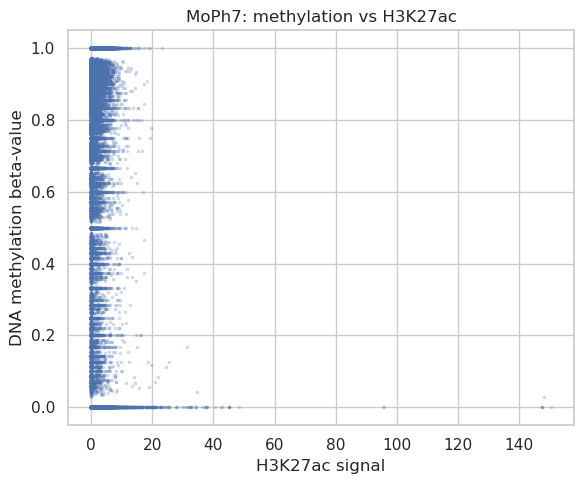

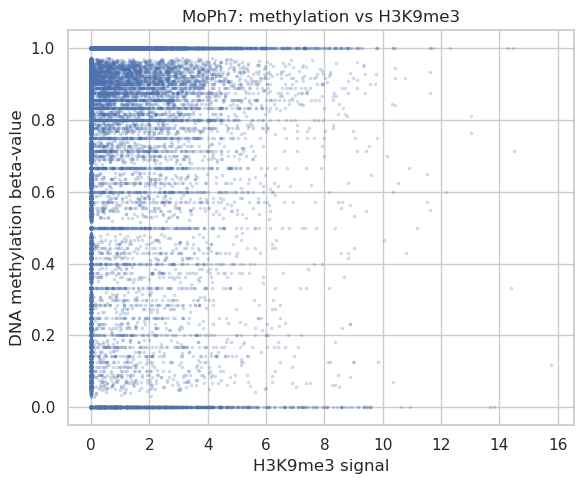

In [6]:
plot_df = df.sample(min(len(df), 50_000), random_state=2)

for track_name in chip_tracks:
    signal_col = f"{track_name}_signal"

    plt.figure(figsize=(6, 5))
    sns.scatterplot(
        data=plot_df,
        x=signal_col,
        y="beta_value",
        s=5,
        alpha=0.25,
        edgecolor=None,
    )
    plt.xlabel(f"{track_name} signal")
    plt.ylabel("DNA methylation beta-value")
    plt.title(f"MoPh7: methylation vs {track_name}")
    plt.tight_layout()
    plt.show()

И вот тут последнее, нужно взять bed файл пиков H3K27Ac, посмотреть метилирование в них и в окружении, сделать анрегированные плот по регионам и добавить контроль как bootstrap. 

## Вопросы

1. Почему H3K27ac может отрицательно коррелировать с DNA methylation?
2. Одинаково ли ведут себя H3K27ac и H3K9me3 относительно метилирования?
3. Почему window-level analysis может быть устойчивее single-CpG analysis?
4. Почему correlation не доказывает причинность?
5. Какие confounders здесь могут быть важны: coverage, GC content, CpG density, mappability?

## Aggregate methylation profile around H3K27ac peaks

Теперь посмотрим метилирование не в отдельных CpG, а вокруг H3K27ac peaks.

Идея:

1. Берем `narrowPeak` файл для H3K27ac.
2. Считаем центр каждого пика.
3. Пересчитываем CpG methylation в 100 bp bins: в каждом окне берем средний `beta_value`.
4. Для каждого пика смотрим окно `±500 kb` от центра.
5. Усредняем methylation profile по всем пикам.
6. Для контроля делаем bootstrap/random control: случайные центры на тех же хромосомах, затем рисуем `mean ± 1 std`.

In [7]:
import numpy as np

h3k27ac_peaks = Path("../../day3_ChIPseq_practice/results/macs/MoPh7_H3K27Ac/MoPh7_H3K27Ac_peaks.narrowPeak")
chrom_sizes_file = Path("../../day1_HiC_practice/data/reference/chrom.sizes")

if not h3k27ac_peaks.exists():
    raise FileNotFoundError(h3k27ac_peaks)
if not chrom_sizes_file.exists():
    raise FileNotFoundError(chrom_sizes_file)

def read_chrom_sizes(path):
    chrom_sizes = {}
    with open(path) as handle:
        for line in handle:
            chrom, size = line.rstrip().split("\t")[:2]
            chrom_sizes[chrom] = int(size)
    return chrom_sizes

chrom_sizes = read_chrom_sizes(chrom_sizes_file)
figures_dir = Path("../results/figures")
tables_dir = Path("../results/tables")
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)


### Binned methylation track, 100 bp

В каждом 100 bp окне считаем среднее метилирование по CpG, которые попали в это окно.

In [8]:
bin_size = 100

meth = pd.read_csv(
    methylation_table,
    sep="\t",
    usecols=["chrom", "start", "beta_value"],
)

meth = meth[meth["chrom"].isin(chrom_sizes)].copy()
meth["bin_start"] = ((meth["start"] - 1) // bin_size * bin_size).astype(int)

meth_bins = (
    meth.groupby(["chrom", "bin_start"], as_index=False)
    .agg(beta_value=("beta_value", "mean"), n_cpg=("beta_value", "size"))
)

meth_bins["bin_end"] = meth_bins["bin_start"] + bin_size
meth_bins.head()

,chrom,bin_start,beta_value,n_cpg,bin_end
0,chr1,3300,0.800000,1,3400
1,chr1,3400,0.919048,10,3500
2,chr1,3500,0.872710,10,3600
3,chr1,3600,0.765987,12,3700
4,chr1,3700,0.857143,2,3800


In [9]:
# Для быстрого доступа сделаем словарь: chromosome -> Series,
# где index = start of 100 bp bin, value = mean beta-value.
methylation_by_chrom = {
    chrom: part.set_index("bin_start")["beta_value"].sort_index()
    for chrom, part in meth_bins.groupby("chrom")
}

print(f"100 bp methylation bins: {len(meth_bins):,}")

100 bp methylation bins: 199,947


### Читаем H3K27ac peaks

Для aggregate plot используем центр каждого peak.

In [10]:
peak_columns = [
    "chrom", "start", "end", "name", "score", "strand",
    "fold_change", "neg_log10_pvalue", "neg_log10_qvalue", "summit",
]

peaks = pd.read_csv(
    h3k27ac_peaks,
    sep="\t",
    names=peak_columns,
    usecols=["chrom", "start", "end"],
)

peaks = peaks[peaks["chrom"].isin(methylation_by_chrom)].copy()
peaks["center"] = ((peaks["start"] + peaks["end"]) / 2).astype(int)
peaks = peaks.sort_values(["chrom", "center"]).reset_index(drop=True)

print(f"H3K27ac peaks used: {len(peaks):,}")
peaks.head()

H3K27ac peaks used: 228


,chrom,start,end,center
0,chr1,204925,205161,205043
1,chr1,369448,369647,369547
2,chr1,371444,371660,371552
3,chr1,430469,431798,431133
4,chr1,780628,780830,780729


### Считаем aggregate profile

Окно вокруг центра peak: `±500 kb`.

Если нужно ускорить занятие, можно уменьшить `flank` или взять подвыборку peaks.

In [11]:
flank = 500_000
n_bootstrap = 5
random_seed = 42

offsets = np.arange(-flank, flank + bin_size, bin_size)
offsets_mb = offsets / 1_000_000

rng = np.random.default_rng(random_seed)

def centers_by_chrom(peaks_table):
    return {
        chrom: part["center"].to_numpy(dtype=int)
        for chrom, part in peaks_table.groupby("chrom")
    }

real_centers = centers_by_chrom(peaks)

def aggregate_methylation_profile(centers):
    profile = np.full(len(offsets), np.nan)
    support = np.zeros(len(offsets), dtype=int)

    for i, offset in enumerate(offsets):
        values = []

        for chrom, centers_array in centers.items():
            track = methylation_by_chrom.get(chrom)
            chrom_size = chrom_sizes.get(chrom)
            if track is None or chrom_size is None or len(centers_array) == 0:
                continue

            bin_starts = ((centers_array + offset) // bin_size) * bin_size
            valid = (bin_starts >= 0) & (bin_starts < chrom_size)
            if not valid.any():
                continue

            vals = track.reindex(bin_starts[valid]).to_numpy()
            vals = vals[~np.isnan(vals)]
            if len(vals):
                values.append(vals)

        if values:
            values = np.concatenate(values)
            profile[i] = values.mean()
            support[i] = len(values)

    return profile, support

real_profile, real_support = aggregate_methylation_profile(real_centers)

In [12]:
def make_random_centers_like_peaks(peaks_table):
    random_parts = []

    for chrom, part in peaks_table.groupby("chrom"):
        chrom_size = chrom_sizes[chrom]
        n = len(part)
        low = flank
        high = max(flank + 1, chrom_size - flank)

        if high <= low:
            continue

        random_centers = rng.integers(low, high, size=n)
        random_parts.append(
            pd.DataFrame({"chrom": chrom, "center": random_centers})
        )

    return pd.concat(random_parts, ignore_index=True)

bootstrap_profiles = []
bootstrap_support = []

for i in range(n_bootstrap):
    random_peaks = make_random_centers_like_peaks(peaks)
    random_profile, random_support = aggregate_methylation_profile(
        centers_by_chrom(random_peaks)
    )
    bootstrap_profiles.append(random_profile)
    bootstrap_support.append(random_support)
    print(f"bootstrap {i + 1}/{n_bootstrap} done")

bootstrap_profiles = np.vstack(bootstrap_profiles)
bootstrap_mean = np.nanmean(bootstrap_profiles, axis=0)
bootstrap_std = np.nanstd(bootstrap_profiles, axis=0)

bootstrap 1/5 done


bootstrap 2/5 done


bootstrap 3/5 done


bootstrap 4/5 done


bootstrap 5/5 done


### Plot

Зеленая линия — среднее метилирование вокруг H3K27ac peaks.

Оранжевая линия — средний random/bootstrap control.

Голубая полоса — `bootstrap mean ± 1 std`.

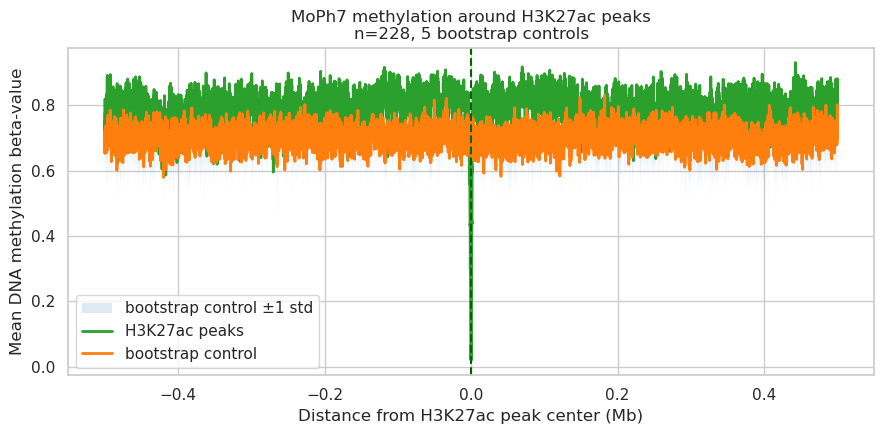

PosixPath('../results/figures/MoPh7_methylation_around_H3K27ac_peaks_bootstrap.png')

In [13]:
plt.figure(figsize=(9, 4.5))

plt.fill_between(
    offsets_mb,
    bootstrap_mean - bootstrap_std,
    bootstrap_mean + bootstrap_std,
    color="tab:blue",
    alpha=0.15,
    linewidth=0,
    label="bootstrap control ±1 std",
)

plt.plot(
    offsets_mb,
    real_profile,
    color="tab:green",
    linewidth=2,
    label="H3K27ac peaks",
)

plt.plot(
    offsets_mb,
    bootstrap_mean,
    color="tab:orange",
    linewidth=2,
    label="bootstrap control",
)

plt.axvline(0, color="darkgreen", linestyle="--", linewidth=1.5)
plt.xlabel("Distance from H3K27ac peak center (Mb)")
plt.ylabel("Mean DNA methylation beta-value")
plt.title(f"MoPh7 methylation around H3K27ac peaks\n"
          f"n={len(peaks):,}, {n_bootstrap} bootstrap controls")
plt.legend(frameon=True)
plt.tight_layout()

profile_plot = figures_dir / "MoPh7_methylation_around_H3K27ac_peaks_bootstrap.png"
plt.savefig(profile_plot, dpi=200)
plt.show()

profile_plot

In [14]:
profile_table = pd.DataFrame({
    "distance_from_peak_center_bp": offsets,
    "distance_from_peak_center_mb": offsets_mb,
    "methylation_H3K27ac_peaks": real_profile,
    "support_H3K27ac_peaks": real_support,
    "bootstrap_mean": bootstrap_mean,
    "bootstrap_std": bootstrap_std,
})

profile_table_path = tables_dir / "MoPh7_methylation_around_H3K27ac_peaks_bootstrap.tsv"
profile_table.to_csv(profile_table_path, sep="\t", index=False)
profile_table.head()

,distance_from_peak_center_bp,distance_from_peak_center_mb,methylation_H3K27ac_peaks,support_H3K27ac_peaks,bootstrap_mean,bootstrap_std
0,-500000,-0.5000,0.747155,32,0.655588,0.050107
1,-499900,-0.4999,0.728645,31,0.653997,0.048911
2,-499800,-0.4998,0.717433,36,0.672543,0.048368
3,-499700,-0.4997,0.726739,36,0.725097,0.054416
4,-499600,-0.4996,0.819556,34,0.684645,0.040733
